# TP Final — EDA Stellar Classification SDSS17

Análisis Exploratorio del dataset **Stellar Classification - SDSS17** (Sloan Digital Sky Survey, Data Release 17).

- **Observaciones:** 100.000
- **Target:** `class` ∈ {`GALAXY`, `STAR`, `QSO`}
- **Features:** 17 columnas (coordenadas, fotometría, IDs de adquisición, redshift, etc.)
- **Fuente:** Kaggle (fedesoriano) — https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17

## Diccionario de variables

| Variable | Descripción |
|---|---|
| `obj_ID` | Identificador único del objeto en el catálogo CAS |
| `alpha` | Ascensión recta (J2000) |
| `delta` | Declinación (J2000) |
| `u`, `g`, `r`, `i`, `z` | Magnitudes en los filtros fotométricos SDSS (UV, verde, rojo, IR cercano, IR) |
| `run_ID` | Número de scan |
| `rerun_ID` | Número de re-procesamiento |
| `cam_col` | Columna de cámara |
| `field_ID` | Número de campo |
| `spec_obj_ID` | ID del objeto espectroscópico |
| `class` | Clase del objeto (target) |
| `redshift` | Corrimiento al rojo |
| `plate` | ID de placa SDSS |
| `MJD` | Modified Julian Date de la observación |
| `fiber_ID` | ID de la fibra óptica |

## Contenido

1. Exploración y comprensión de los datos
2. Análisis de nulos y duplicados
3. Análisis de las variables categóricas
4. Análisis de las variables numéricas
5. Análisis bivariado por clase
6. Mapa del cielo
7. Análisis de outliers
8. Análisis de correlaciones
9. Feature engineering preview — índices de color
10. Columnas de identificadores
11. Pairplot reducido
12. Hallazgos principales


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

sns.set_theme()
pd.set_option("display.max_columns", None)


## Exploración y comprensión de los datos

### Cargar el dataset

In [35]:
df = pd.read_csv("star_classification.csv")
df.shape

(100000, 18)

### Describir las características principales

In [36]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [37]:
df.tail()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470
99999,1.237661e+18,196.896053,49.464643,22.62171,21.79745,20.60115,20.00959,19.28075,3650,301,4,60,8.343152e+18,GALAXY,0.542944,7410,57104,851


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


**Observaciones iniciales:**

- 100.000 filas × 18 columnas.
- `rerun_ID` tiene un único valor (301) — columna constante.
- Los mínimos de `u`, `g` y `z` son `-9999`, valor centinela que indica **missing encubierto**.
- `redshift` tiene mínimo negativo cercano a 0 (esperado para estrellas cercanas) y máximo ~7 (cuásares lejanos).
- IDs (`obj_ID`, `spec_obj_ID`) son numéricos pero categóricos por naturaleza.


# Análisis de nulos y duplicados

In [40]:
df.isna().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [41]:
df.duplicated().sum()

0

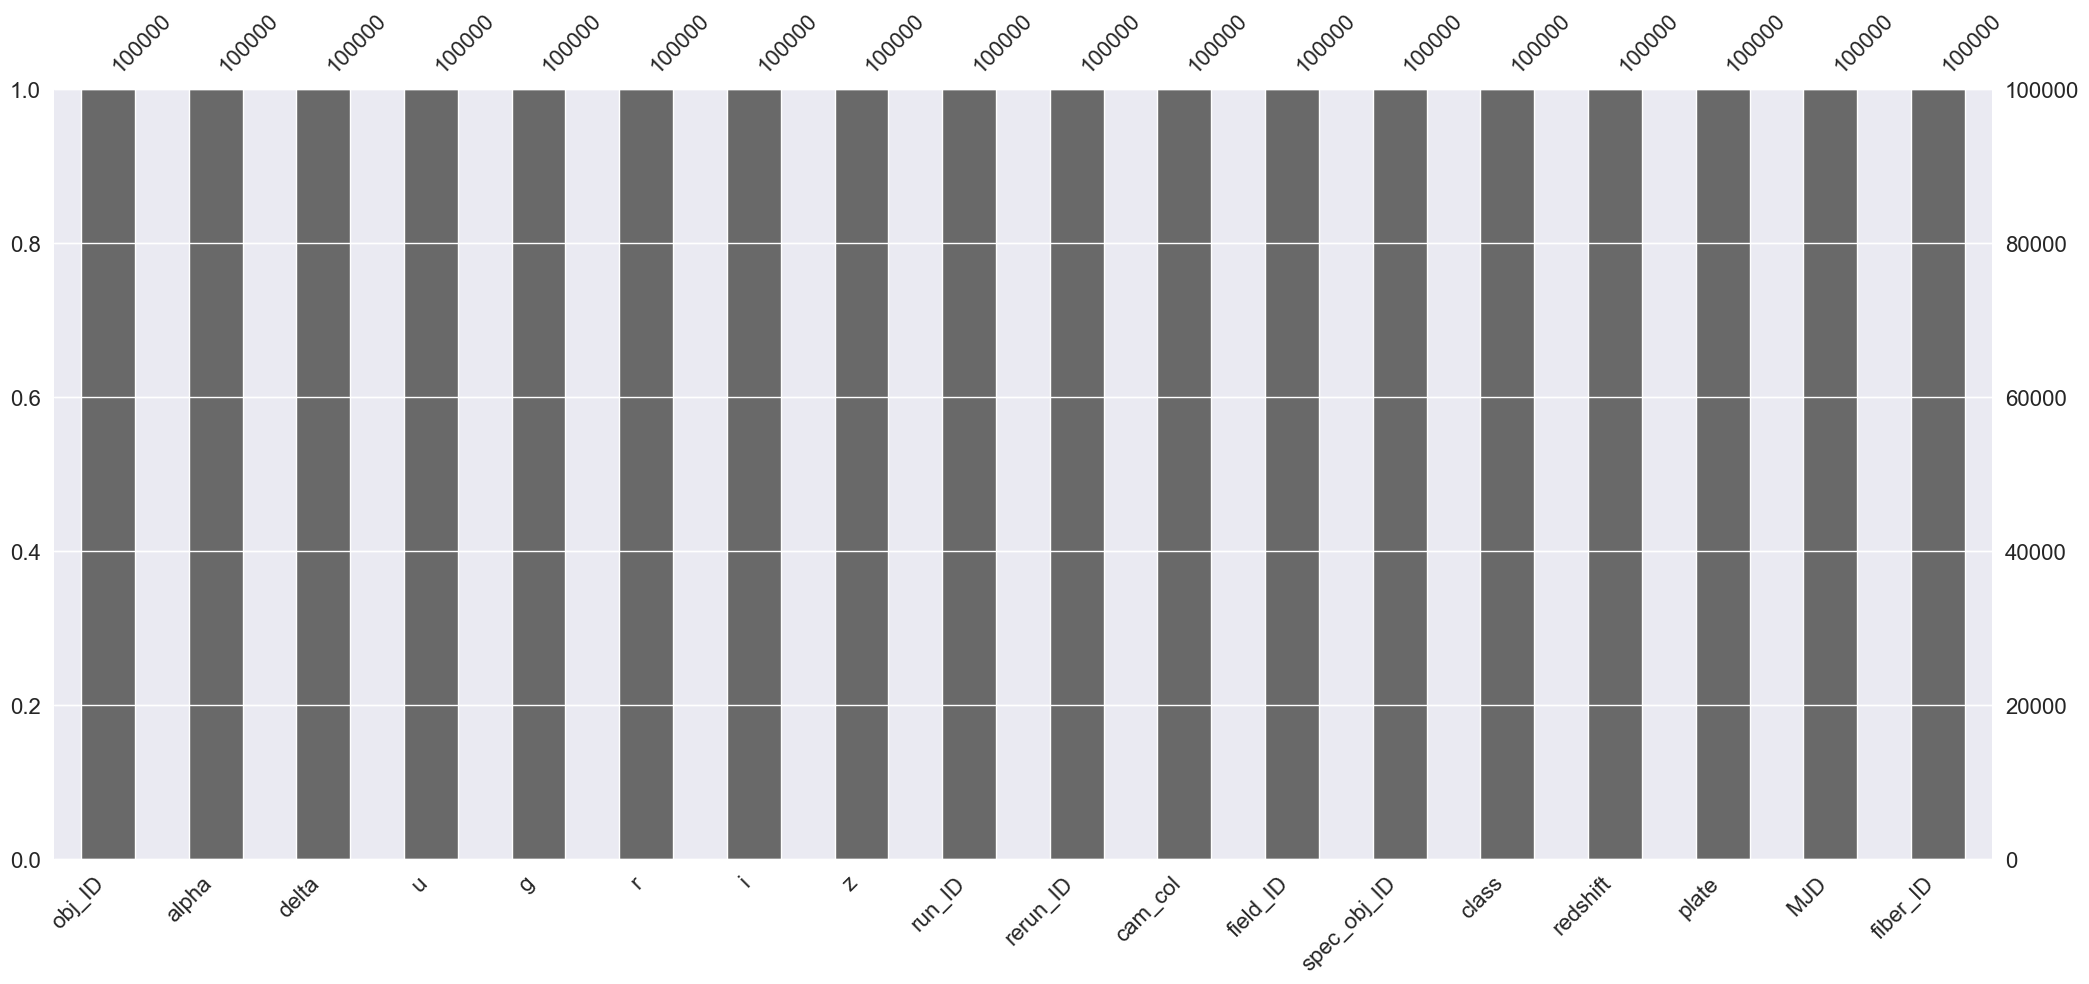

In [42]:
msno.bar(df)
plt.show()

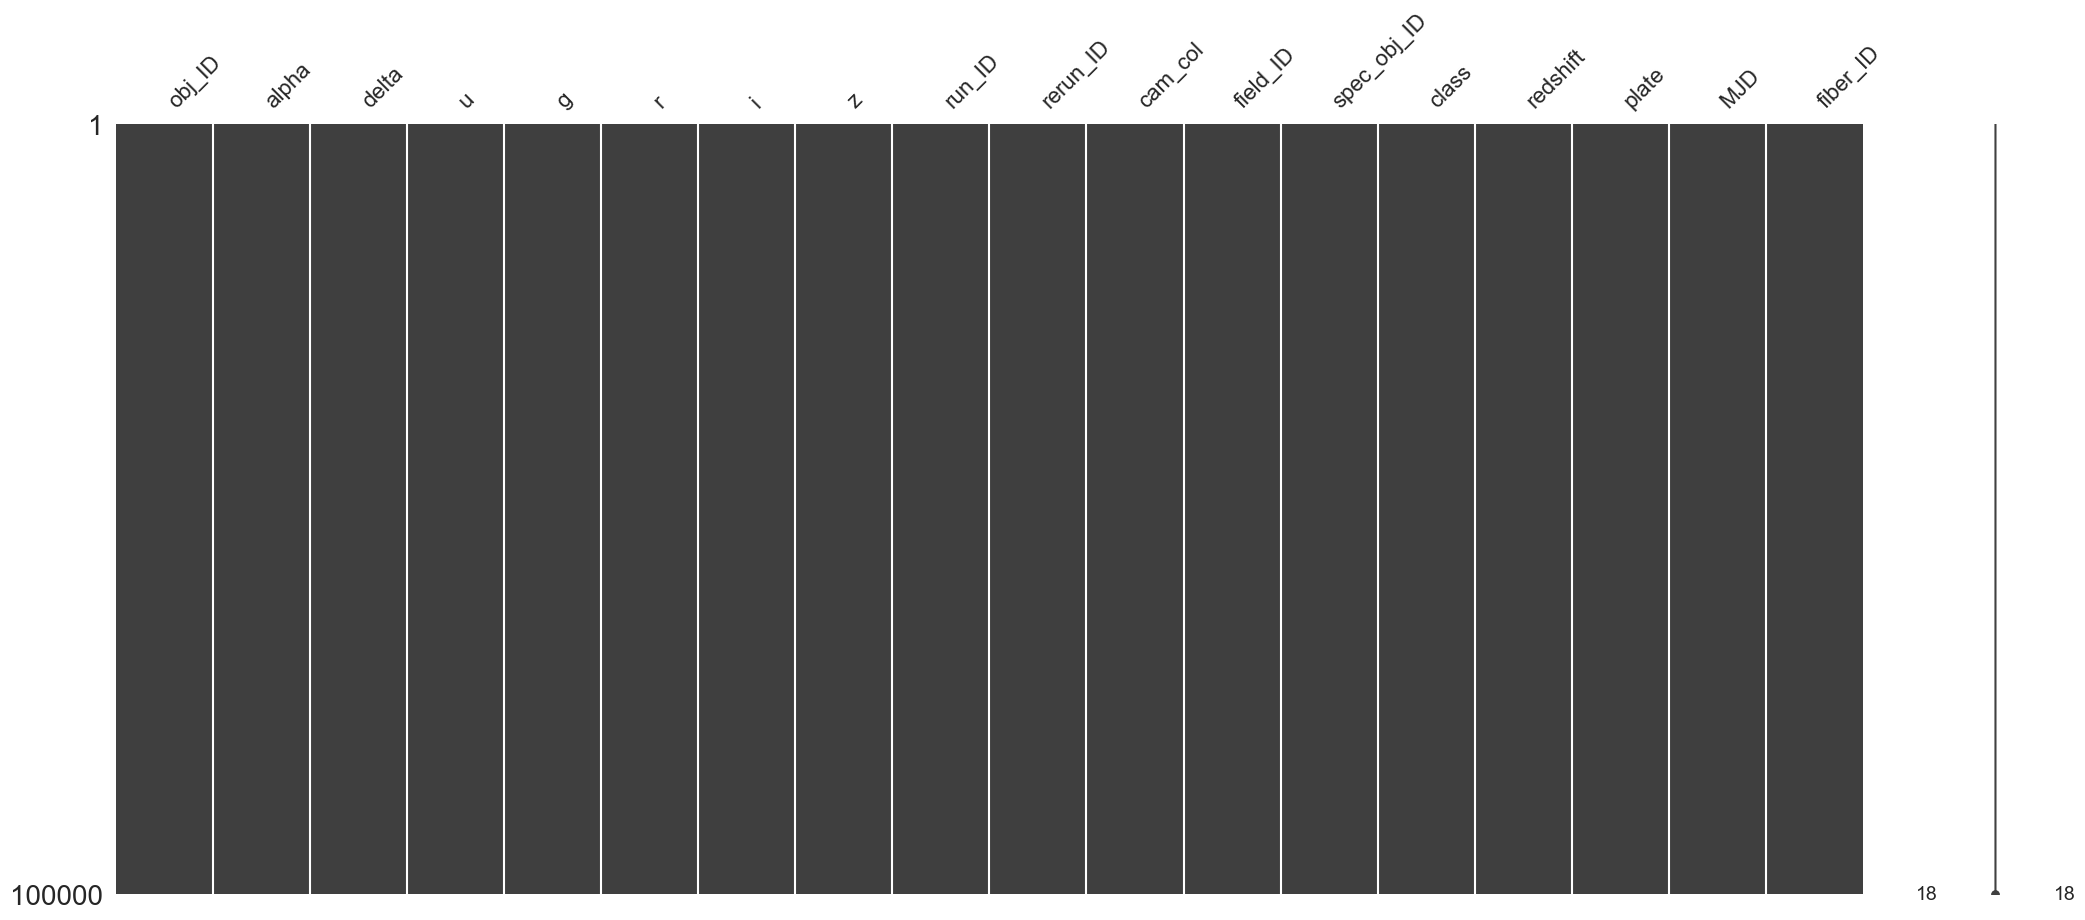

In [43]:
msno.matrix(df)
plt.show()

### Centinelas `-9999` (missing encubiertos)

In [44]:
(df[["u", "g", "z"]] == -9999).sum()

u    1
g    1
z    1
dtype: int64

In [45]:
# Filas afectadas por al menos un centinela en u/g/z
mask_sentinel = (df[["u", "g", "z"]] == -9999).any(axis=1)
print(f"Filas con centinela: {mask_sentinel.sum()}")
df[mask_sentinel].head()

Filas con centinela: 1


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


**Hallazgo:** no hay `NaN` declarados ni duplicados. Solo **1 fila** contiene el valor centinela `-9999` simultáneamente en `u`, `g` y `z` (`obj_ID ≈ 1.237649e+18`, clase STAR). Cantidad insignificante frente a las 100.000 observaciones (0,001%) — no hay evidencia de patrón sistemático MNAR/MAR.

**Decisión simple:** eliminar esa única fila en preprocesamiento. No justifica imputación ni análisis de mecanismo de missingness.

# Análisis de las variables categóricas

In [46]:
df["class"] = df["class"].astype("category")
df["class"].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [47]:
df["class"].value_counts(normalize=True).round(3) * 100

class
GALAXY    59.4
STAR      21.6
QSO       19.0
Name: proportion, dtype: float64

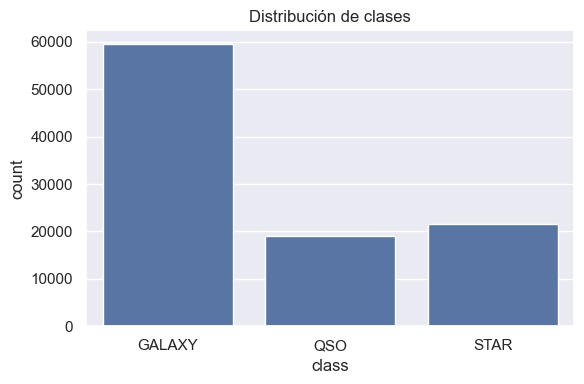

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="class", data=df, ax=ax)
ax.set_title("Distribución de clases")
plt.tight_layout(); plt.show()

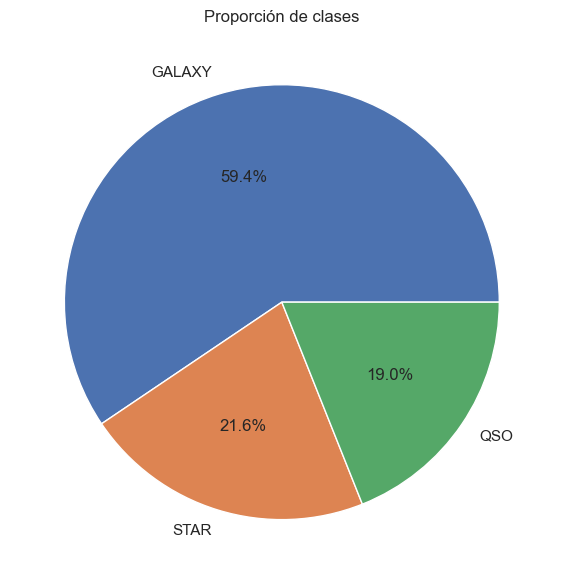

In [75]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["class"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", shadow=False)
ax.set_title("Proporción de clases")
plt.tight_layout(); plt.show()

**Hallazgo:** dataset desbalanceado.

- GALAXY ≈ 59,4%
- STAR ≈ 21,6%
- QSO ≈ 19,0%

El desbalance afectará al modelado y deberá manejarse (class weights, SMOTE, etc.) en etapas posteriores.


# Análisis de las variables numéricas

Se analizan las variables físicas y observacionales. Para cada una: estadísticos (media/mediana/moda), histograma con líneas de referencia y boxplot.

In [50]:
num_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift", "plate", "MJD"]
sentinel_cols = {"u", "g", "z"}

def analizar_var(col):
    serie = df[col]
    if col in sentinel_cols:
        serie_clean = serie[serie != -9999]
        print(f"--- {col} (filtrando centinelas -9999: {len(serie) - len(serie_clean)} filas) ---")
    else:
        serie_clean = serie
        print(f"--- {col} ---")
    print(f"media   {col}: {serie_clean.mean():.4f}")
    print(f"mediana {col}: {serie_clean.median():.4f}")
    print(f"moda    {col}: {serie_clean.mode().iloc[0]:.4f}")
    print(f"std     {col}: {serie_clean.std():.4f}")
    print(f"skew    {col}: {serie_clean.skew():.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    mean, std = serie_clean.mean(), serie_clean.std()
    ax.hist(serie_clean, bins=40, alpha=0.7, color="steelblue")
    ax.axvline(serie_clean.mode().iloc[0], color="yellow", ls="--", lw=2, label="Moda")
    ax.axvline(serie_clean.median(),       color="red",    ls="--", lw=2, label="Mediana")
    ax.axvline(mean,                        color="green",  ls="--", lw=2, label="Media")
    ax.axvline(mean - 3 * std, color="red", ls=":", label="Mean − 3·STD")
    ax.axvline(mean + 3 * std, color="red", ls=":", label="Mean + 3·STD")
    ax.set_title(f"Distribución de {col}")
    ax.legend()
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.boxplot(x=serie_clean, color="lightblue", ax=ax)
    ax.set_title(f"Boxplot de {col}")
    plt.tight_layout(); plt.show()


--- alpha ---
media   alpha: 177.6291
mediana alpha: 180.9007
moda    alpha: 34.7496
std     alpha: 96.5022
skew    alpha: -0.0285


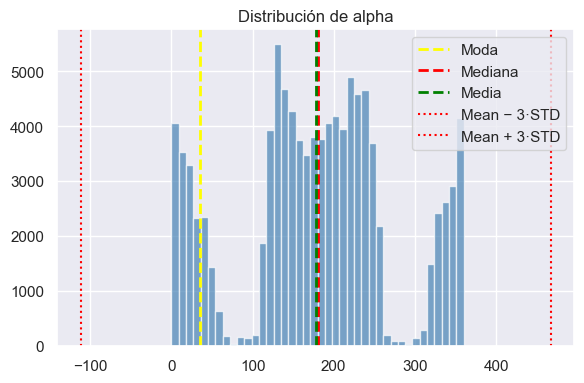

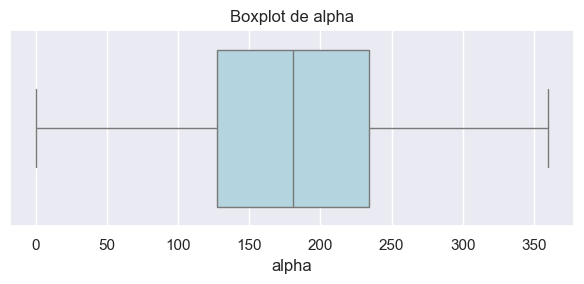

In [51]:
analizar_var("alpha")

--- delta ---
media   delta: 24.1353
mediana delta: 23.6459
moda    delta: -0.6019
std     delta: 19.6447
skew    delta: 0.1751


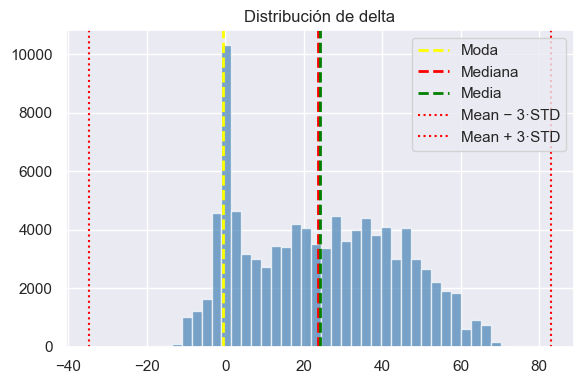

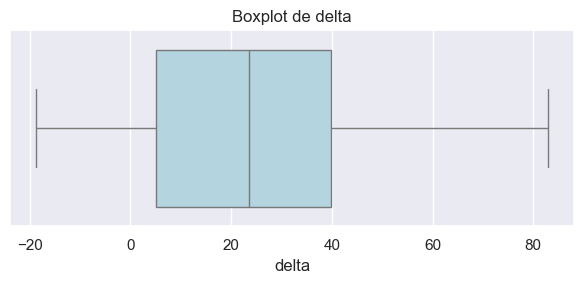

In [52]:
analizar_var("delta")

--- u (filtrando centinelas -9999: 1 filas) ---
media   u: 22.0807
mediana u: 22.1791
moda    u: 24.6347
std     u: 2.2511
skew    u: -0.0703


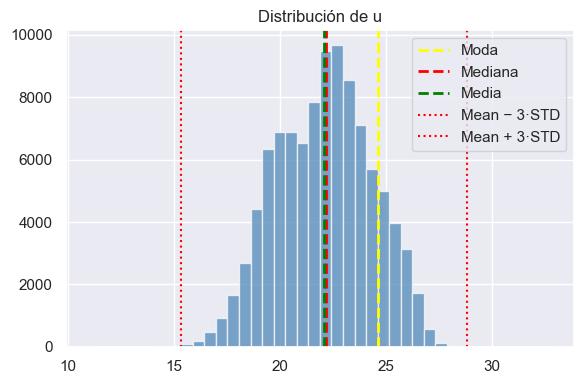

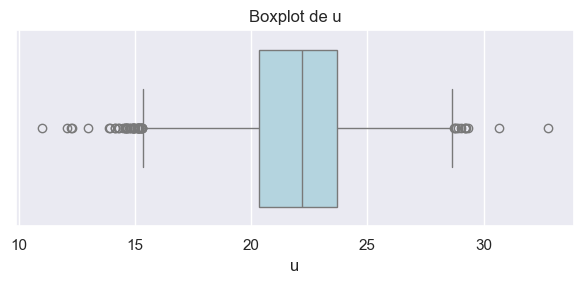

In [53]:
analizar_var("u")

--- g (filtrando centinelas -9999: 1 filas) ---
media   g: 20.6316
mediana g: 21.0999
moda    g: 25.1144
std     g: 2.0374
skew    g: -0.4280


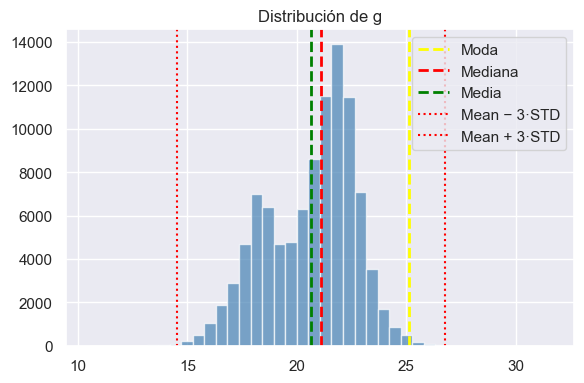

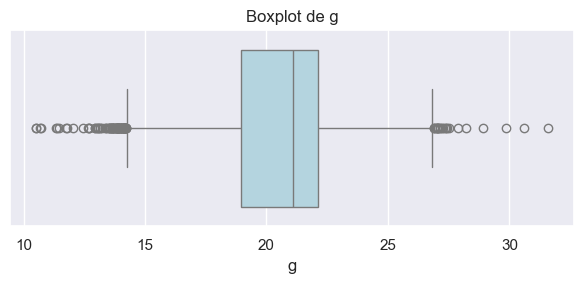

In [54]:
analizar_var("g")

--- r ---
media   r: 19.6458
mediana r: 20.1253
moda    r: 24.8020
std     r: 1.8548
skew    r: -0.5079


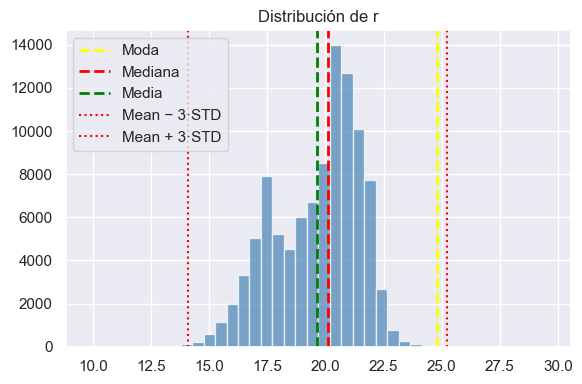

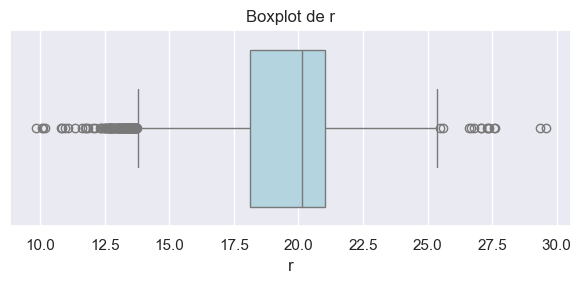

In [55]:
analizar_var("r")

--- i ---
media   i: 19.0849
mediana i: 19.4051
moda    i: 24.3618
std     i: 1.7579
skew    i: -0.4042


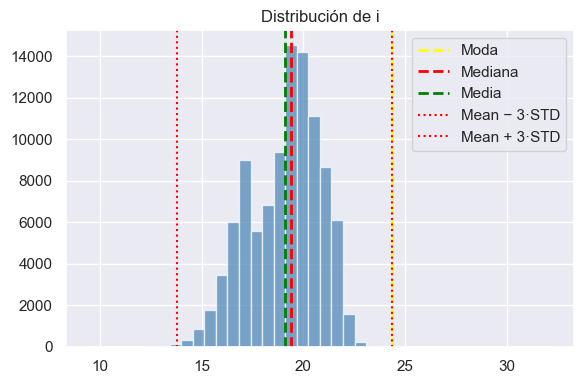

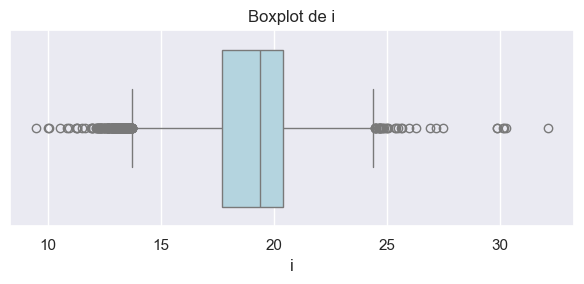

In [56]:
analizar_var("i")

--- z (filtrando centinelas -9999: 1 filas) ---
media   z: 18.7690
mediana z: 19.0046
moda    z: 22.8269
std     z: 1.7660
skew    z: -0.2568


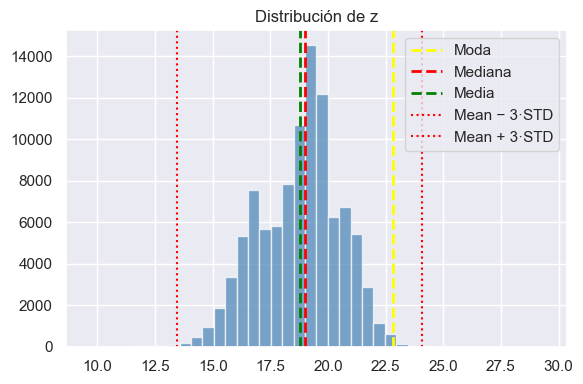

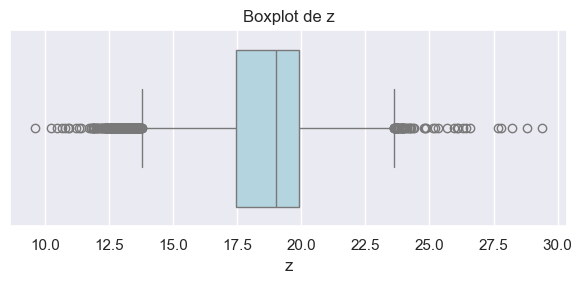

In [57]:
analizar_var("z")

--- redshift ---
media   redshift: 0.5767
mediana redshift: 0.4242
moda    redshift: 0.0000
std     redshift: 0.7307
skew    redshift: 2.5236


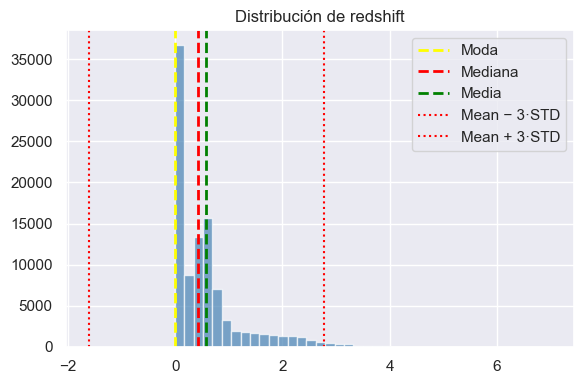

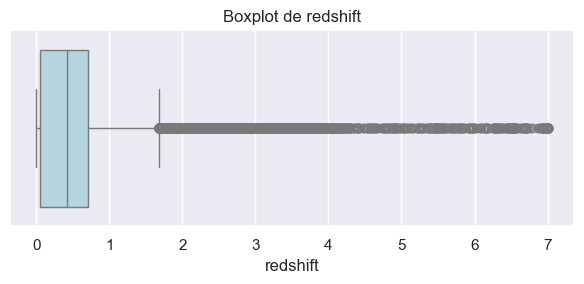

In [58]:
analizar_var("redshift")

--- plate ---
media   plate: 5137.0097
mediana plate: 4987.0000
moda    plate: 6301.0000
std     plate: 2952.3034
skew    plate: 0.1985


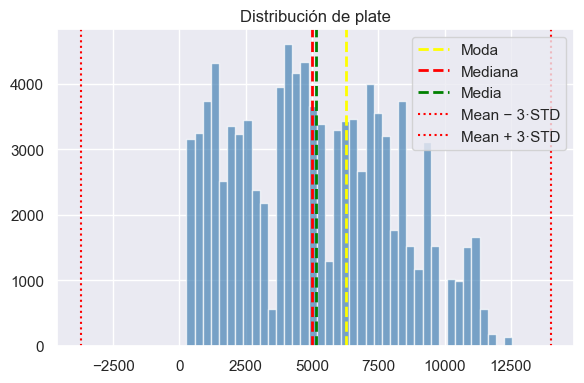

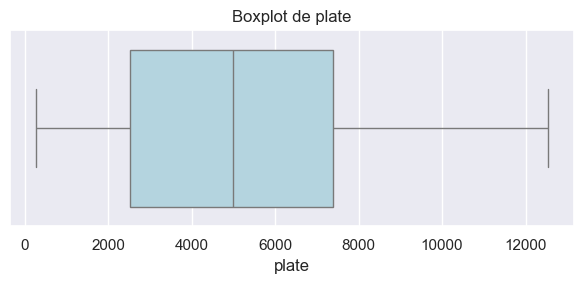

In [59]:
analizar_var("plate")

--- MJD ---
media   MJD: 55588.6475
mediana MJD: 55868.5000
moda    MJD: 56625.0000
std     MJD: 1808.4842
skew    MJD: -0.3819


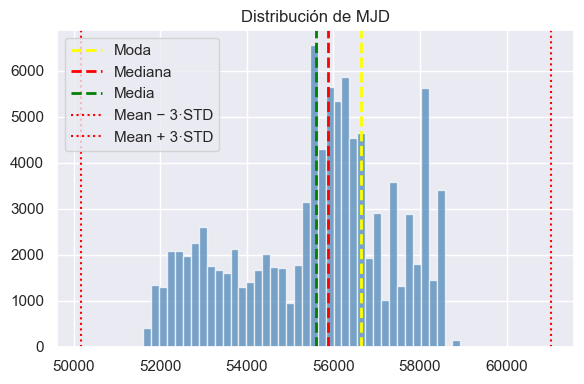

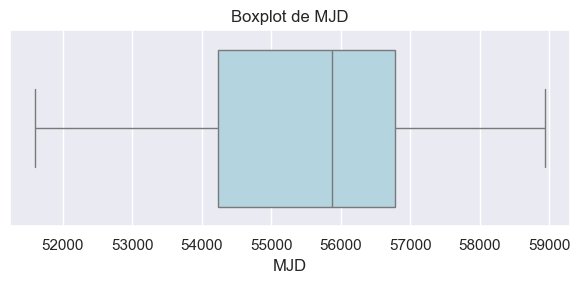

In [60]:
analizar_var("MJD")

**Observaciones de las distribuciones:**

- `alpha` (ascensión recta): cobertura no uniforme entre 0° y 360° — el SDSS no cubre todo el cielo.
- `delta` (declinación): concentrada en valores positivos (hemisferio norte, donde está Apache Point).
- `u`, `g`, `z`: distribuciones razonables tras filtrar `-9999`.
- `r`, `i`: distribuciones unimodales con leve sesgo hacia magnitudes brillantes (~17–22).
- `redshift`: fuertemente sesgada a la derecha, con un pico cerca de 0 (estrellas) y cola larga (cuásares).
- `plate`, `MJD`: distribución multimodal por campañas de observación; útiles solo como proxy temporal.


# Análisis bivariado por clase

### Distribuciones por clase (histogramas)

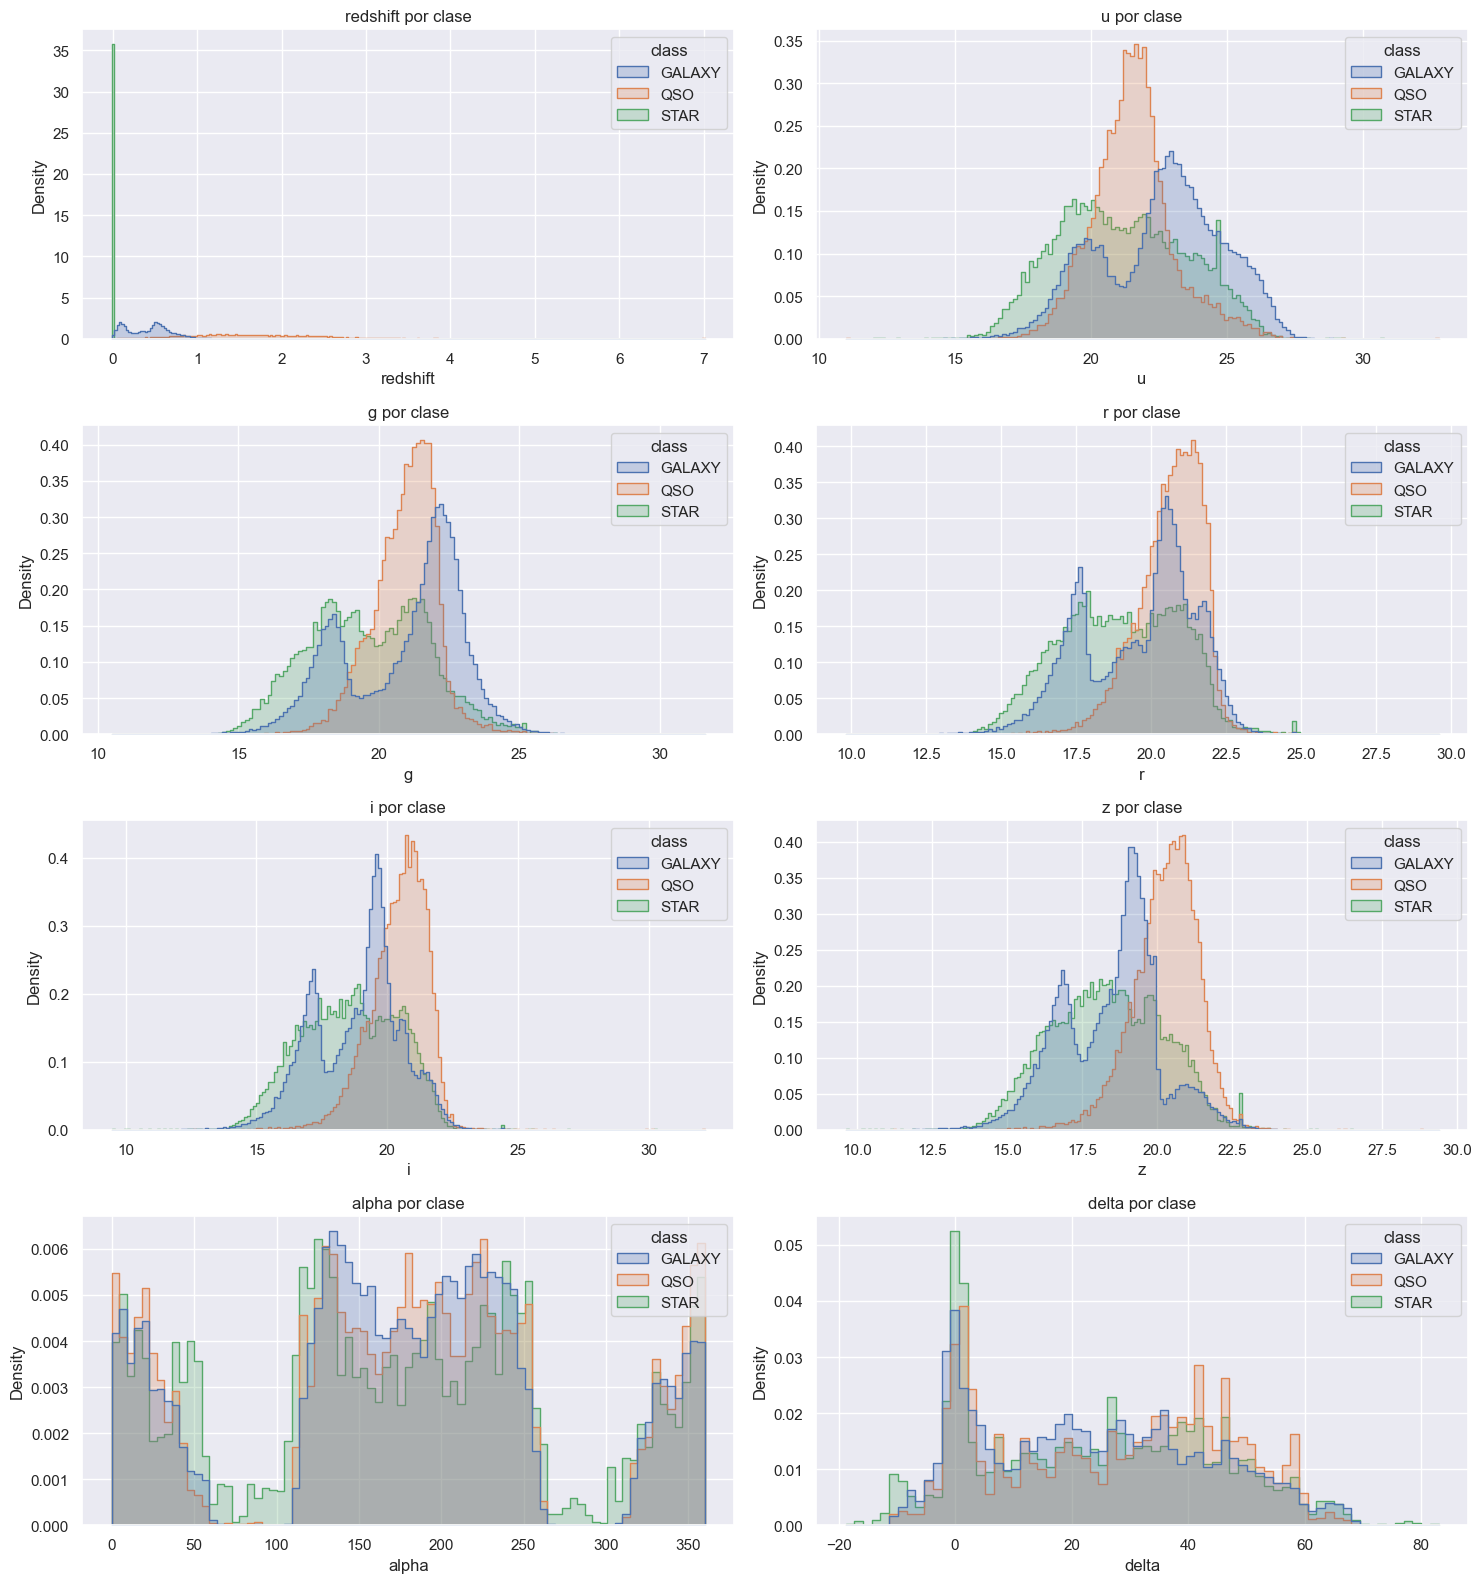

In [61]:
target_cols = ["redshift", "u", "g", "r", "i", "z", "alpha", "delta"]
df_plot = df.copy()
for c in sentinel_cols:
    df_plot.loc[df_plot[c] == -9999, c] = np.nan

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for ax, col in zip(axes.flat, target_cols):
    sns.histplot(data=df_plot, x=col, hue="class", element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} por clase")
plt.tight_layout(); plt.show()

## Análisis de la gráfica "redshift por clase"
Si observas detenidamente el primer gráfico (arriba a la izquierda):

* Estrellas (STAR - Verde): Tienen un redshift de prácticamente cero. Esto se debe a que están dentro de nuestra propia galaxia (la Vía Láctea) y muy cerca de nosotros.
* Galaxias comunes (GALAXY - Azul): Tienen su pico de densidad concentrado muy cerca de 0 y se extienden máximo hasta un redshift de 1. Esto significa que las galaxias normales detectadas en este estudio son relativamente cercanas.
* Cuásares (QSO - Naranja): Su curva comienza donde terminan las galaxias (cerca de redshift 1) y se extiende de forma casi plana entre 1 y 4 o más.

------------------------------
## ¿Por qué los cuásares muestran un redshift tan alto?
Esta gráfica demuestra visualmente dos fenómenos clave:

* El brillo permite verlos a gran distancia: Las galaxias normales que están a un redshift de 3 o 4 son tan tenues que los telescopios convencionales no las detectan (por eso la línea azul cae a cero). En cambio, el núcleo del cuásar es tan sumamente brillante que viaja miles de millones de años luz y sigue siendo visible.
* Mirada al pasado del Universo: Como la luz tarda tiempo en viajar, ver un objeto con redshift alto significa ver el universo cuando era muy joven. Los cuásares eran muy comunes en el universo primitivo (hace 10.000 millones de años), mientras que las galaxias estables y tranquilas actuales (línea azul) se observan en nuestra época cósmica más reciente.

------------------------------
## Las gráficas de magnitudes (u, g, r, i, z)
Las otras gráficas muestran filtros astronómicos de color (desde el ultravioleta u hasta el infrarrojo cercano z).

* Fíjate cómo en todos los filtros, la curva naranja (QSO) suele estar desplazada hacia valores más altos en el eje horizontal.
* En astronomía, números más altos en estas escalas significan que el objeto es más tenue en el cielo. Los cuásares, a pesar de ser intrínsecamente monstruosos, se ven más tenues en los telescopios que las estrellas de nuestra galaxia simplemente porque están a distancias cosmológicas extremas.

¿Te gustaría profundizar en cómo se utiliza el filtro u, g, r, i, z para clasificar automáticamente estos objetos con inteligencia artificial?

Se ven más tenues simplemente porque la luz se dispersa y se debilita a medida que viaja por el espacio.
Aunque un cuásar emite billones de veces más luz que nuestro Sol, esa luz debe viajar miles de millones de años luz para llegar a la Tierra. En ese viaje tan largo, la luz se esparce en todas direcciones, por lo que a nuestros telescopios solo llega una cantidad diminuta de fotones. Es el mismo efecto por el cual un faro gigante de un barco a 20 kilómetros de distancia se ve como un punto débil, mientras que la pequeña linterna de un celular a un metro de tus ojos se ve muchísimo más brillante.
Acepto el trato, ¡vamos a profundizar en cómo la inteligencia artificial usa estos filtros astronómicos para clasificarlos!

------------------------------
## El "truco" de la IA: El color astronómico
En astronomía, las letras u, g, r, i, z representan la magnitud (el brillo) de un objeto visto a través de cinco filtros de color diferentes (desde el ultravioleta hasta el infrarrojo).
Para entrenar un modelo de Inteligencia Artificial (como un árbol de decisión o una red neuronal), los astrónomos no usan solo el brillo absoluto, sino la resta entre estos filtros (por ejemplo: $u - g$, $g - r$, $r - i$). A estas restas se les llama índices de color.

## ¿Cómo distingue la IA un cuásar de una estrella o galaxia?
Si miras con atención las gráficas de tu imagen, notarás que las curvas de densidad de cada objeto se cruzan, pero tienen picos y formas muy diferentes en cada filtro. La IA analiza estas diferencias simultáneamente:

   1. El corte del Lyman-Alpha (El secreto de los Cuásares): Debido a que los cuásares están extremadamente lejos (alto redshift), el gas hidrógeno del universo intergaláctico absorbe casi toda su luz ultravioleta. Para la IA, un cuásar se detecta al instante porque es completamente invisible o extremadamente tenue en el filtro u (ultravioleta), pero se vuelve muy brillante en los filtros r, i o z. Ninguna estrella común de nuestra galaxia hace eso.
   2. El perfil de las Galaxias: Las galaxias normales contienen poblaciones de estrellas viejas y polvo, lo que les da una firma de color muy mezclada y más "roja" (picos altos en i y z), pero con una distribución más ancha y predecible que la IA identifica con facilidad.
   3. El perfil de las Estrellas: Las estrellas de nuestra galaxia siguen una física muy estricta (el espectro de cuerpo negro). Sus brillos a lo largo de los filtros u, g, r, i, z están perfectamente alineados según su temperatura. La IA reconoce este patrón térmico y descarta las estrellas de inmediato.


### Boxplots por clase

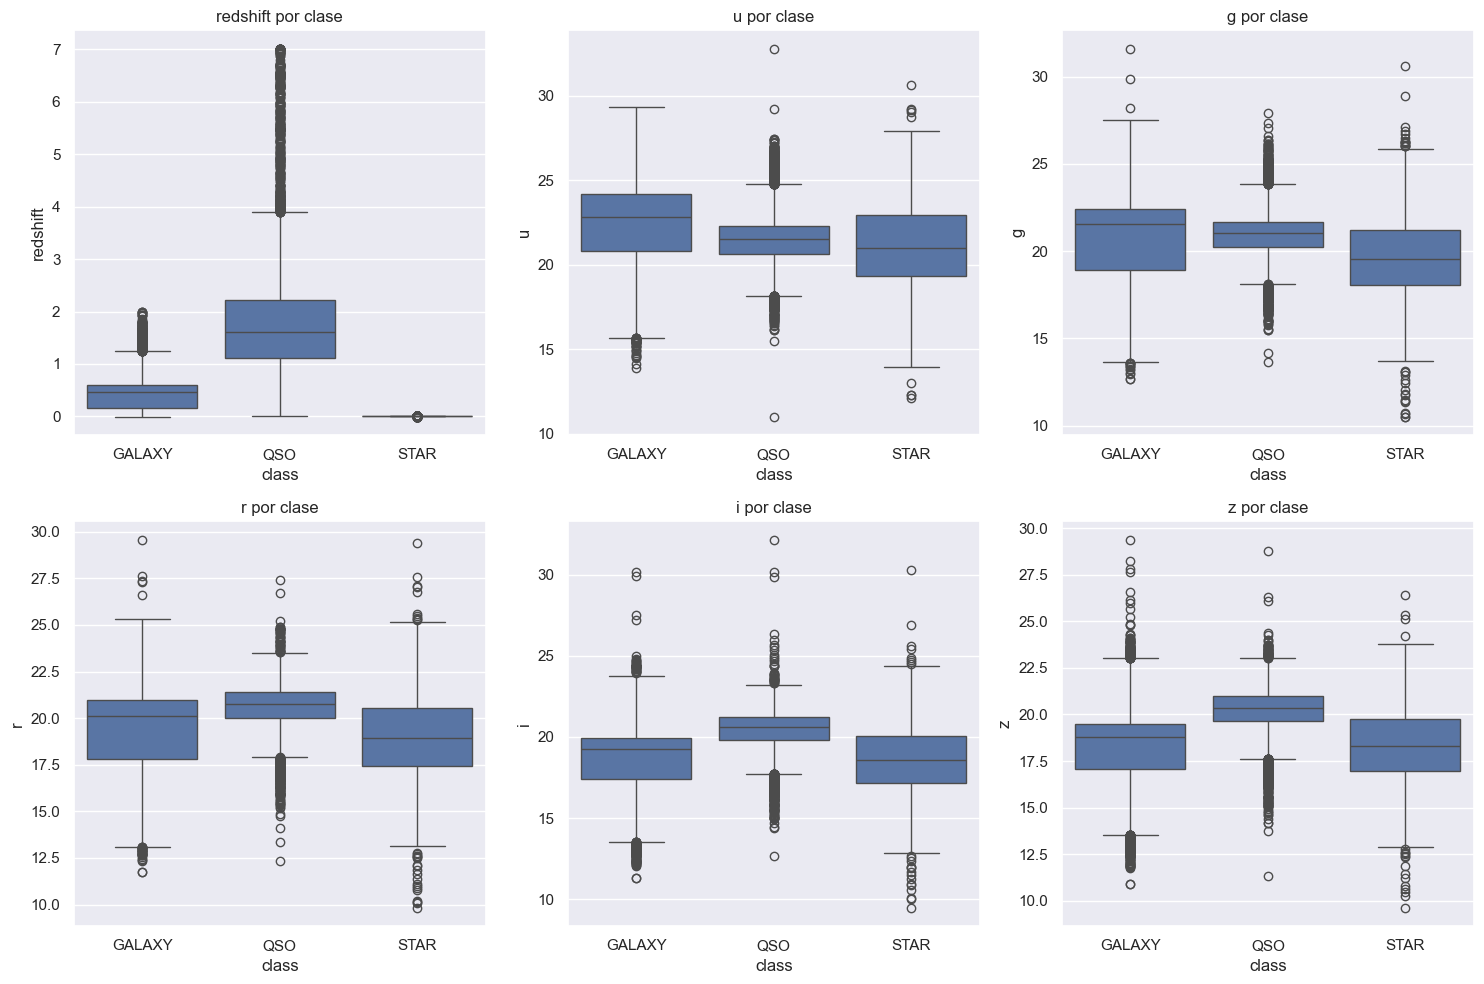

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, ["redshift", "u", "g", "r", "i", "z"]):
    sns.boxplot(data=df_plot, x="class", y=col, ax=ax)
    ax.set_title(f"{col} por clase")
plt.tight_layout(); plt.show()

**Hallazgos clave del bivariado:**

- `redshift` separa fuertemente las clases: STAR ≈ 0, GALAXY en valores intermedios (0,05–0,5), QSO en valores altos (0,5–7). **Feature dominante.**
- Las magnitudes (`u`, `g`, `r`, `i`, `z`) por sí solas no separan tan bien como `redshift`, pero las **diferencias entre filtros** (índices de color) sí — se explora en la sección de feature engineering.
- `alpha`/`delta` no separan clases (esperado: la posición en el cielo no determina el tipo de objeto, salvo sesgos de muestreo).


### Mapa del cielo

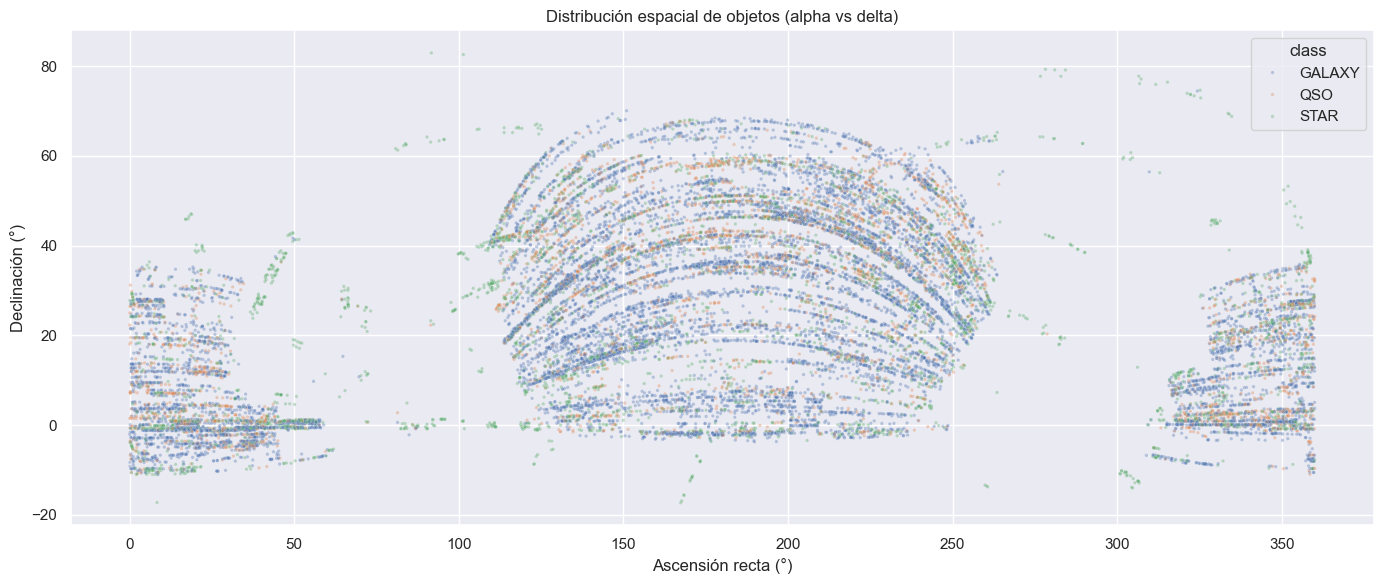

In [63]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(data=df.sample(20000, random_state=0),
                x="alpha", y="delta", hue="class",
                alpha=0.35, s=6, ax=ax)
ax.set_title("Distribución espacial de objetos (alpha vs delta)")
ax.set_xlabel("Ascensión recta (°)")
ax.set_ylabel("Declinación (°)")
plt.tight_layout(); plt.show()

**Hallazgo:** se observan las regiones de muestreo características del SDSS (franjas y stripe 82). Las tres clases aparecen mezcladas en las regiones cubiertas → las coordenadas no son discriminantes por sí mismas.


# Análisis de outliers

Detección por IQR (1.5×) sobre las variables numéricas físicas. Se reporta el conteo por columna sin eliminar registros.

In [64]:
def contar_outliers_iqr(serie, sentinel=None):
    s = serie if sentinel is None else serie[serie != sentinel]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return int(((s < low) | (s > high)).sum()), float(low), float(high)

filas = []
for col in num_cols:
    sentinel = -9999 if col in sentinel_cols else None
    n_out, low, high = contar_outliers_iqr(df[col], sentinel=sentinel)
    filas.append({"variable": col, "outliers_iqr": n_out,
                  "limite_inf": round(low, 3), "limite_sup": round(high, 3)})

outliers_df = pd.DataFrame(filas).sort_values("outliers_iqr", ascending=False)
outliers_df

,variable,outliers_iqr,limite_inf,limite_sup
7,redshift,8990,-0.920,1.679
6,z,319,13.770,23.612
5,i,198,13.736,24.393
4,r,132,13.772,25.408
3,g,98,14.227,26.862
2,u,55,15.350,28.690
0,alpha,0,-32.047,393.460
1,delta,0,-46.985,92.034
8,plate,0,-4785.375,14711.625
9,MJD,0,50419.500,60591.500


**Nota:** los valores `-9999` se descartan antes del cálculo. Algunos outliers son astronómicamente reales (cuásares con redshift muy alto, estrellas muy brillantes) y no deberían eliminarse a ciegas.


# Análisis de correlaciones

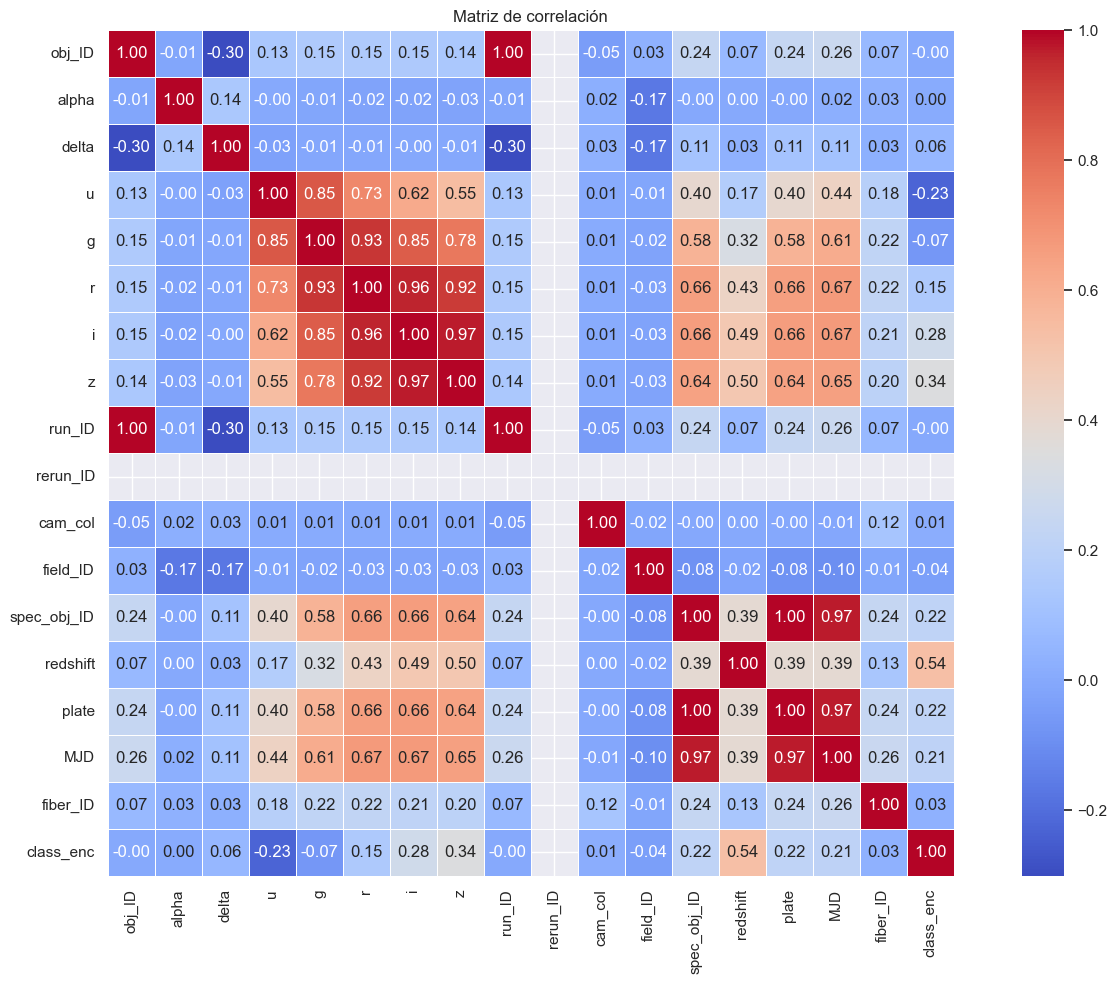

In [65]:
df_corr = df.copy()
df_corr["class_enc"] = df_corr["class"].map({"GALAXY": 0, "STAR": 1, "QSO": 2}).astype(int)
for c in sentinel_cols:
    df_corr.loc[df_corr[c] == -9999, c] = np.nan

corr = df_corr.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout(); plt.show()

In [66]:
corr["class_enc"].drop("class_enc").sort_values()

u             -0.226930
g             -0.066894
field_ID      -0.038044
run_ID        -0.000049
obj_ID        -0.000047
alpha          0.004552
cam_col        0.014476
fiber_ID       0.032053
delta          0.056643
r              0.150691
MJD            0.207262
spec_obj_ID    0.215722
plate          0.215722
i              0.284396
z              0.340914
redshift       0.536822
rerun_ID            NaN
Name: class_enc, dtype: float64

**Hallazgos:**

- `redshift` tiene la correlación más alta con la clase (consistente con el análisis univariado).
- `plate`, `MJD`, `spec_obj_ID` correlacionan con la clase **por sesgo de muestreo** (campañas de observación específicas se dedicaron a tipos concretos de objetos) — no son features físicas.
- `rerun_ID` da `NaN` porque es constante → debe descartarse.
- Las magnitudes `u`/`g`/`r`/`i`/`z` están **fuertemente correlacionadas entre sí** (multicolinealidad esperada): justifica usar índices de color como features derivadas.


# Feature engineering preview — índices de color

Los índices de color (`u-g`, `g-r`, `r-i`, `i-z`) son combinaciones clásicas en astronomía que aíslan información espectral y suelen separar mejor las clases que las magnitudes crudas.

In [67]:
df_color = df_plot[["u", "g", "r", "i", "z", "class"]].dropna().copy()
df_color["u_g"] = df_color["u"] - df_color["g"]
df_color["g_r"] = df_color["g"] - df_color["r"]
df_color["r_i"] = df_color["r"] - df_color["i"]
df_color["i_z"] = df_color["i"] - df_color["z"]

color_idx = ["u_g", "g_r", "r_i", "i_z"]
df_color[color_idx].describe().T

,count,mean,std,min,25%,50%,75%,max
u_g,99999.0,1.449096,1.179332,-12.74814,0.631245,1.32171,2.044565,18.62495
g_r,99999.0,0.985806,0.734675,-12.31861,0.379810,0.93146,1.577985,14.31517
r_i,99999.0,0.560912,0.501518,-14.64907,0.216320,0.47980,0.892205,12.20580
i_z,99999.0,0.315877,0.420396,-13.16249,0.134500,0.33803,0.474080,13.42710


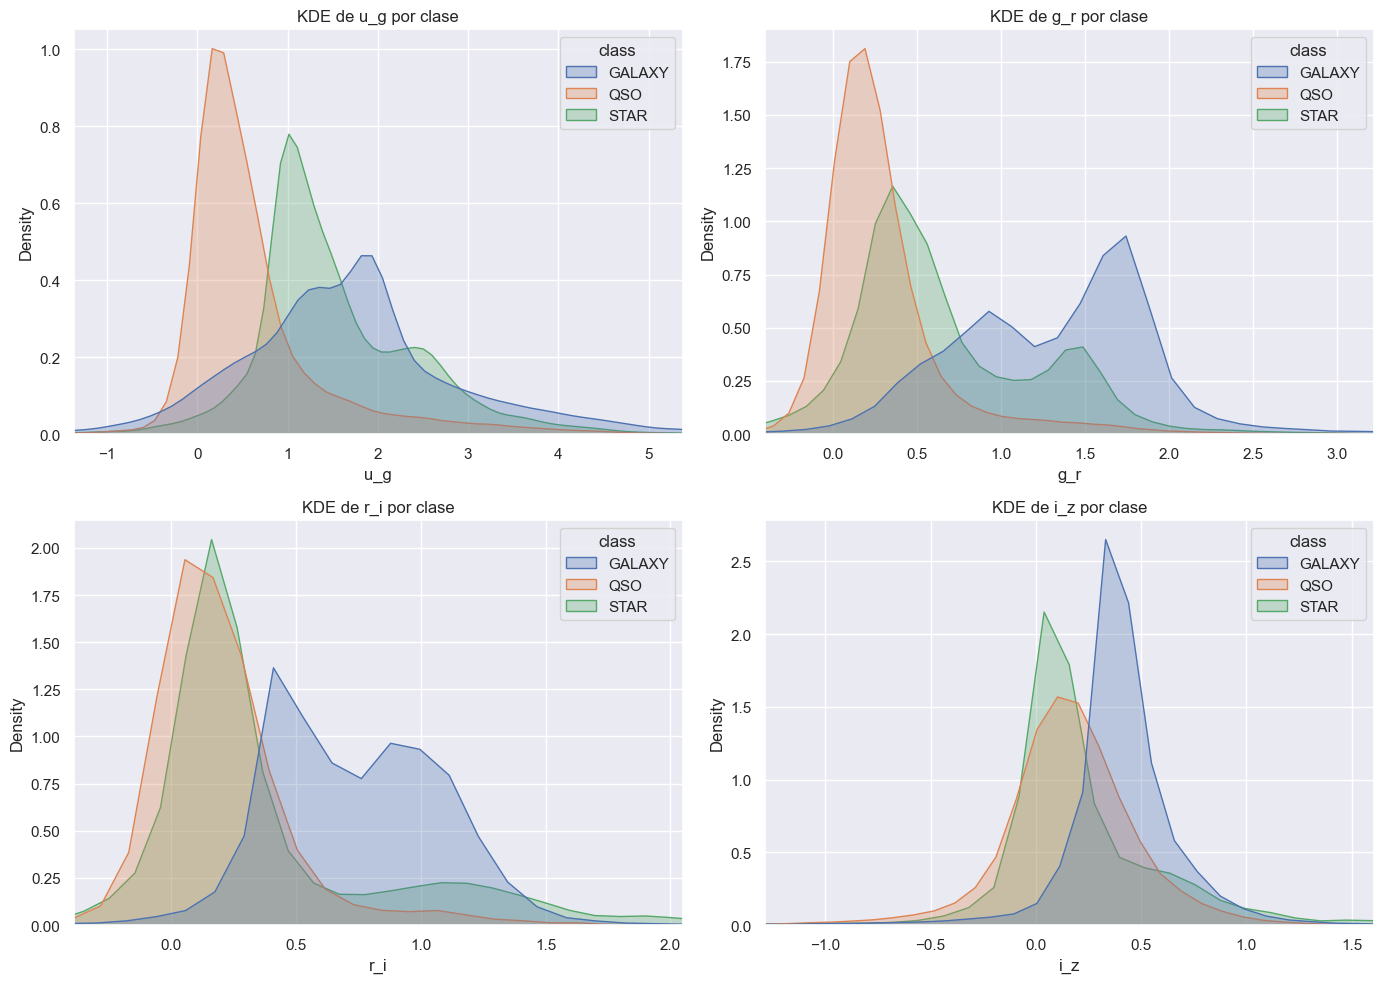

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, color_idx):
    sns.kdeplot(data=df_color, x=col, hue="class", common_norm=False,
                fill=True, alpha=0.3, ax=ax)
    ax.set_title(f"KDE de {col} por clase")
    ax.set_xlim(df_color[col].quantile(0.005), df_color[col].quantile(0.995))
plt.tight_layout(); plt.show()

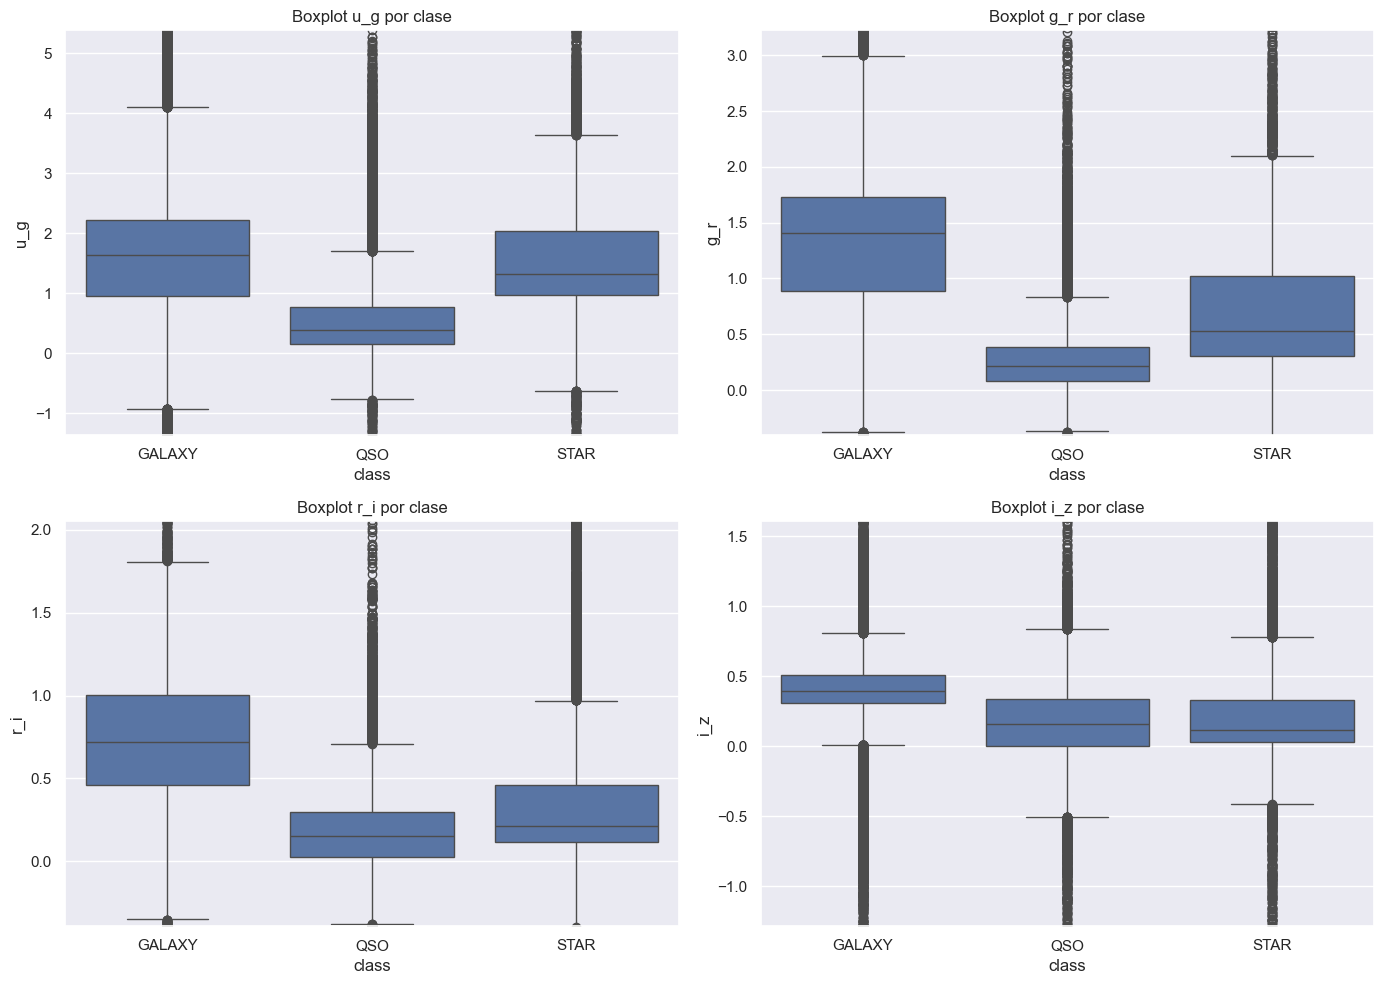

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, color_idx):
    sns.boxplot(data=df_color, x="class", y=col, ax=ax)
    ax.set_title(f"Boxplot {col} por clase")
    ax.set_ylim(df_color[col].quantile(0.005), df_color[col].quantile(0.995))
plt.tight_layout(); plt.show()

**Hallazgo:** los índices de color muestran separabilidad por clase, en especial `u_g` y `g_r`. Son candidatos sólidos como features derivadas para el modelado.


# Columnas de identificadores

In [70]:
id_cols = ["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID",
           "spec_obj_ID", "fiber_ID", "plate", "MJD"]
df[id_cols].nunique().sort_values()

rerun_ID            1
cam_col             6
run_ID            430
field_ID          856
fiber_ID         1000
MJD              2180
plate            6284
obj_ID          78053
spec_obj_ID    100000
dtype: int64

**Hallazgos:**

- `rerun_ID`: 1 único valor → **constante, descartar.**
- `cam_col`: 6 valores → categórica de la cámara.
- `obj_ID`, `spec_obj_ID`: identificadores únicos por fila → sin valor predictivo, descartar.
- `run_ID`, `field_ID`, `fiber_ID`: identificadores técnicos de adquisición → sin valor físico, descartar.
- `plate`, `MJD`: aunque correlacionan con la clase por sesgo de muestreo, **no son features físicas** y deberían descartarse para evitar data leakage si el objetivo es generalizar a observaciones futuras.


### Validación de `spec_obj_ID`

Según la documentación, dos observaciones con el mismo `spec_obj_ID` deben compartir la misma `class`. Verificamos esa restricción y de paso medimos cuántos `spec_obj_ID` se repiten.

In [71]:
spec_counts = df["spec_obj_ID"].value_counts()
print(f"spec_obj_ID totales:     {len(spec_counts)}")
print(f"spec_obj_ID únicos:      {(spec_counts == 1).sum()}")
print(f"spec_obj_ID repetidos:   {(spec_counts > 1).sum()}")
print(f"Máx. repeticiones:       {spec_counts.max()}")

spec_obj_ID totales:     100000
spec_obj_ID únicos:      100000
spec_obj_ID repetidos:   0
Máx. repeticiones:       1


In [72]:
# Para cada spec_obj_ID, contar cuántas clases distintas aparecen
clases_por_spec = df.groupby("spec_obj_ID", observed=True)["class"].nunique()
violaciones = clases_por_spec[clases_por_spec > 1]
print(f"spec_obj_ID con clases inconsistentes: {len(violaciones)}")
violaciones.head()

spec_obj_ID con clases inconsistentes: 0


Series([], Name: class, dtype: int64)

In [73]:
# Detalle de los spec_obj_ID repetidos: cuántas filas comparten cada uno
# y verificación rápida de que todas comparten la misma clase
repetidos = spec_counts[spec_counts > 1]
print(f"Filas involucradas en spec_obj_ID repetidos: {repetidos.sum()}")

if len(repetidos) > 0:
    ejemplo_id = repetidos.index[0]
    print(f"\nEjemplo spec_obj_ID = {ejemplo_id}:")
    df[df["spec_obj_ID"] == ejemplo_id][["spec_obj_ID", "class", "obj_ID", "MJD", "plate", "fiber_ID"]]

Filas involucradas en spec_obj_ID repetidos: 0


**Resultado:** todos los `spec_obj_ID` son únicos (1 fila por ID). No hay repeticiones → no aplica la restricción de "clases compartidas" mencionada en la documentación para este subset de 100k filas.

**Implicancia para el modelado:** sin grupos repetidos, `train_test_split` estándar (estratificado por `class`) es suficiente. No es necesario `GroupShuffleSplit`/`GroupKFold`. `spec_obj_ID` queda confirmado como identificador único sin valor predictivo → descartar.

# Pairplot reducido

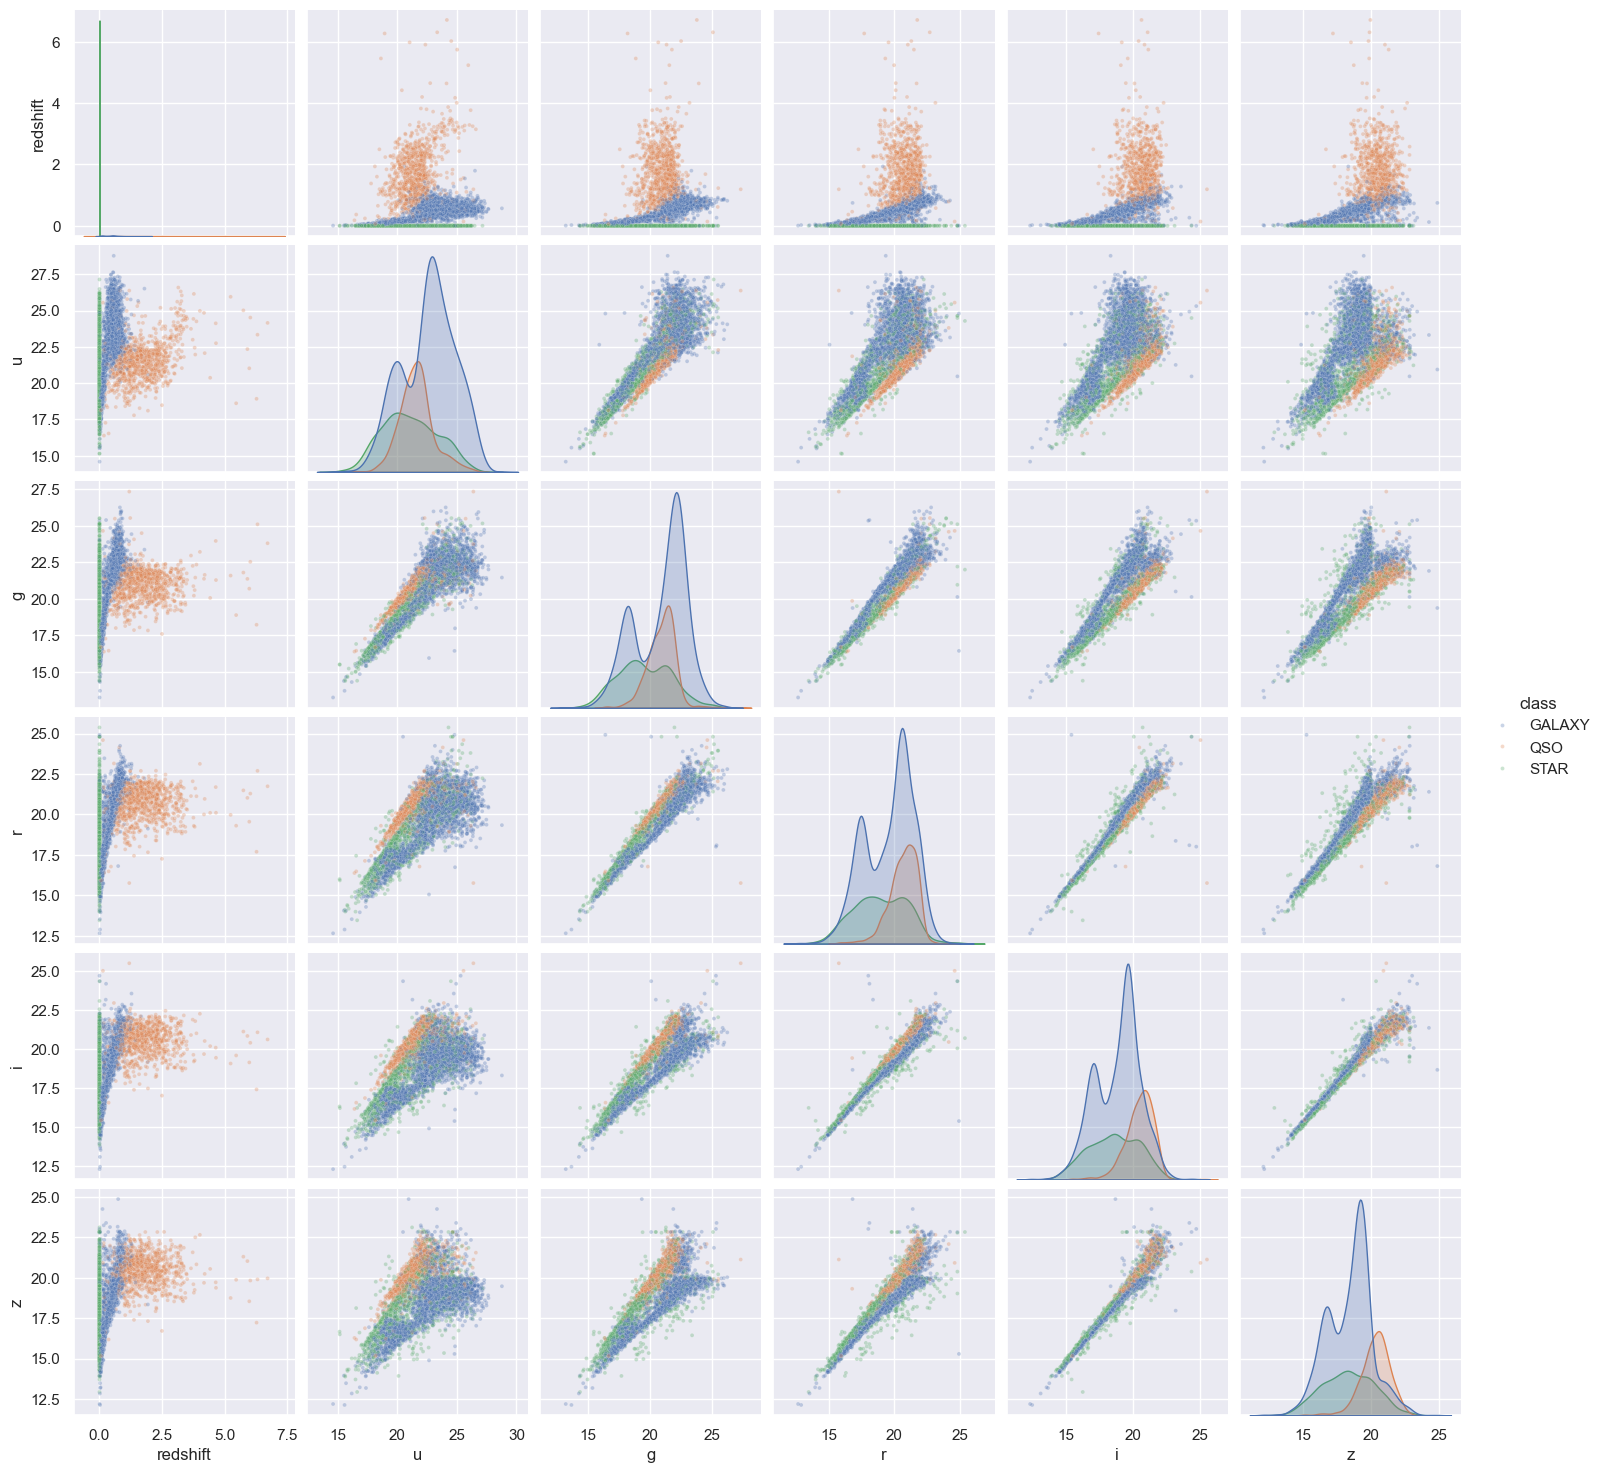

In [74]:
sample = df_plot[["redshift", "u", "g", "r", "i", "z", "class"]].dropna().sample(5000, random_state=0)
sns.pairplot(sample, hue="class", diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8})
plt.show()

**Hallazgo:** se confirma visualmente que `redshift` es la variable más discriminante; las magnitudes solas presentan solapamiento alto, pero al combinarse muestran estructura útil.


# Hallazgos principales

- **Tamaño y target:** 100.000 filas, target `class` ∈ {GALAXY, STAR, QSO}.
- **Desbalance de clases:** GALAXY ~59% / STAR ~22% / QSO ~19% → se requerirá tratamiento (class weights, SMOTE).
- **Missing:** no hay `NaN` ni duplicados. Una sola fila tiene centinela `-9999` en `u`/`g`/`z` (0,001%) → eliminar directamente, sin análisis adicional.
- **`spec_obj_ID`:** todos únicos, sin repeticiones → `train_test_split` estándar estratificado es suficiente, no se necesita `GroupKFold`.
- **Variable dominante:** `redshift` es de lejos la feature más informativa para separar las clases.
- **Magnitudes:** `u`/`g`/`r`/`i`/`z` están altamente correlacionadas entre sí (multicolinealidad). Los **índices de color** (`u-g`, `g-r`, `r-i`, `i-z`) son combinaciones útiles que mejoran la separabilidad.
- **Columnas a descartar:**
  - `rerun_ID` (constante)
  - `obj_ID`, `spec_obj_ID`, `run_ID`, `field_ID`, `fiber_ID`, `cam_col` (IDs sin valor físico)
  - `plate`, `MJD` (correlacionan con la clase por sesgo temporal de muestreo → potencial data leakage)
- **Coordenadas (`alpha`, `delta`):** no separan clases por sí mismas, solo reflejan la cobertura del SDSS.
- **Outliers:** detectados por IQR en redshift y magnitudes; algunos son astronómicamente reales (QSOs lejanos) y no deben eliminarse a ciegas.

## Próximos pasos (fuera de este EDA)

1. Eliminar la fila con centinelas `-9999`.
2. Descartar columnas sin valor físico.
3. Crear índices de color como features.
4. Manejar el desbalance de clases.
5. Estandarizar y entrenar modelos (baseline con Logistic Regression / RandomForest; comparar con SVM, XGBoost, LightGBM, CatBoost).
